# HR Attrition Prediction & Retention ROI — Company I

**A data-driven proof of concept for reducing turnover at an IT consulting firm**

---

## Executive Summary

**Business problem.** Company I (an IT consulting firm) is losing people faster than it wants to. Every departure means lost billable hours, a disrupted client relationship, and a slow, expensive replacement search. This notebook builds a model that flags which employees are at risk of leaving and why, then turns that into a costed retention program a non-technical exec can actually sign off on.

**Approach.**
1. EDA on who's leaving and why (Section 3).
2. Feature engineering around tenure, stress, satisfaction (Section 4).
3. Logistic Regression baseline, then an Optuna-tuned LightGBM, to see if it's actually worth the extra complexity (Sections 5-6).
4. Ditch the default 0.5 cutoff for a threshold picked off the Precision-Recall curve, since the classes are imbalanced (Section 7).
5. SHAP explanations so HR gets specific reasons per employee instead of a black-box score (Section 8).
6. Turn the model output into a retention program with a Net ROI number (Sections 9-10).

**Results at a glance.**

| Metric | Value |
|---|---|
| Best model | LightGBM (Optuna-tuned) |
| Test AUC-ROC | *run the notebook, see the Executive Recap cell at the end* |
| Test F1-Score | *run the notebook, see the Executive Recap cell at the end* |
| Optimal decision threshold | *run the notebook, see the Executive Recap cell at the end* |
| Targeted Retention Program, Net ROI | *run the notebook, see the Executive Recap cell at the end* |

> **Note on the figures above:** this version adds hyperparameter tuning, threshold optimization, and more features on top of the original PoC, so the numbers moved from any earlier run. An earlier version had Net ROI around **$91,889.96 (87.5% ROI)** for the pilot cohort. Useful as a ballpark, not something to paste in unverified. **Run every cell top to bottom against `dataset/data.csv`, then copy the numbers from the "Executive Recap" cell (end of Section 10) into the table above before sharing this.**

**Bottom line for the business.** If the model's high-risk segment holds up, a fairly cheap retention push (stay interviews + market-rate salary bumps) targeted at *High Risk*/*Flight Risk* employees pays for itself several times over. Full breakdown and assumptions in Section 10.

---

### Table of Contents
1. [Setup & Configuration](#1-setup--configuration)
2. [Data Loading & Preprocessing](#2-data-loading--preprocessing)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis-eda)
4. [Feature Engineering & Preprocessing Pipeline](#4-feature-engineering--preprocessing-pipeline)
5. [Baseline Model — Logistic Regression](#5-baseline-model--logistic-regression)
6. [Model Training — LightGBM + Hyperparameter Optimization](#6-model-training--lightgbm-with-hyperparameter-optimization)
7. [Threshold Optimization](#7-threshold-optimization-precision-recall-curve)
8. [Model Explainability — SHAP](#8-model-explainability--shap)
9. [Risk Segmentation](#9-risk-segmentation)
10. [Business Impact Simulation (ROI)](#10-business-impact-simulation-roi)
11. [Conclusion & Business Recommendations](#11-conclusion--business-recommendations)

## 1. Setup & Configuration

In [44]:
import logging
import random
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#modeling stuff
import lightgbm as lgb
import optuna
import shap
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)  #optuna is way too chatty otherwise

In [45]:
# using logging instead of print() so stage progress is actually readable
#note: the ROI report near the end still uses print() directly, that output is meant for a human reading the notebook, not a log file
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("attrition_pipeline")

In [46]:
RANDOM_STATE: int = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

#config lives here so every tunable number is in one place instead of buried in a function
DATA_DIR: str = "dataset"
DATA_FILENAME: str = "data.csv"
DATA_PATH: Path = Path(DATA_DIR) / DATA_FILENAME

ARTIFACTS_DIR: str = "artifacts"
ARTIFACTS_PATH: Path = Path(ARTIFACTS_DIR)
ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)

TEST_SIZE: float = 0.2
CV_FOLDS: int = 5

#Optuna
OPTUNA_N_TRIALS: int = 30  # kept small on purpose, see Section 6
OPTUNA_TIMEOUT_SECONDS: int = 180
OPTUNA_CV_FOLDS: int = 5
EARLY_STOPPING_ROUNDS: int = 30
FINAL_VALIDATION_SIZE: float = 0.15  #carved out of X_train, never touches X_test

# default 0.5 threshold is a bad pick on an imbalanced target, real search happens in Section 7
THRESHOLD_METRIC: str = "f1"

def build_risk_bins(threshold: float) -> Tuple[List[float], List[str]]:
    """Risk-tier bin edges, anchored to the model's own threshold instead of fixed numbers."""
    remaining = 1.0 - threshold
    mid = threshold + remaining / 3
    upper = threshold + 2 * remaining / 3
    bins = [0.0, threshold, mid, upper, 1.0]
    labels = ["Low Risk", "Medium Risk", "High Risk", "Flight Risk (Critical)"]
    return bins, labels
HIGH_RISK_CATEGORIES: List[str] = ["High Risk", "Flight Risk (Critical)"]

# replacement cost as a fraction of annual salary. 1.5 comes from published HR benchmarks
# (Gallup/SHRM cite 50%-200% depending on seniority, Columbia research put the average around 150%)
# https://www.shrm.org/executive-network/insights/myth-replaceability-preparing-loss-key-employees
# still an external number though, not Company I's actual cost, hence the sensitivity table in Section 10
REPLACEMENT_COST_MULTIPLIER: float = 1.5
INTERVENTION_COST_PER_EMPLOYEE: float = 3000.0
INTERVENTION_EFFECTIVENESS: float = 0.20

#below this many employees a group's attrition rate is basically noise, see summarize_attrition_by_group
MIN_GROUP_SIZE_FOR_RATE: int = 20

# only real identifier columns go here, constant columns get auto-detected in load_and_preprocess
ID_COLUMNS: List[str] = ["EmployeeNumber"]

logger.info("Configuration loaded")

09:13:30 | INFO     | Configuration loaded


## 2. Data Loading & Preprocessing

In [47]:
def load_and_preprocess(filepath: Path) -> pd.DataFrame:
    """Loads the CSV, encodes the target, drops ID/constant columns."""
    if not filepath.exists():
        raise FileNotFoundError(
            f"Dataset not found at: {filepath.resolve()}. "
            f"Expected a CSV at '{DATA_DIR}/{DATA_FILENAME}' relative to the notebook."
        )

    logger.info(f"Loading dataset from {filepath}")
    df = pd.read_csv(filepath)

    #pandas >= 3.0 stores text as a dedicated "str" dtype, not "object", so dtype == object
    #silently misses it here and the target never gets encoded
    if "Attrition" in df.columns and not pd.api.types.is_numeric_dtype(df["Attrition"]):
        df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

    # auto-detect constant columns instead of hardcoding names, so a future data refresh
    # with a different constant column still gets caught
    constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    existing_id_cols = [c for c in ID_COLUMNS if c in df.columns]
    drop_cols = sorted(set(constant_cols) | set(existing_id_cols))

    df = df.drop(columns=drop_cols)
    logger.info(f"Dropped {len(constant_cols)} auto-detected constant column(s): {constant_cols}")
    logger.info(f"Dropped {len(existing_id_cols)} identifier column(s): {existing_id_cols}")
    logger.info(f"Loaded dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
    return df


def build_data_dictionary(df: pd.DataFrame) -> pd.DataFrame:
    """Human-readable column descriptions for the columns that matter most (not exhaustive)."""
    descriptions = {
        "Attrition": "Employee left the company (1=Yes, 0=No) — TARGET",
        "Age": "Employee age in years",
        "MonthlyIncome": "Monthly salary in currency units",
        "YearsAtCompany": "Tenure with current employer",
        "JobLevel": "Job seniority (1-5 scale)",
        "OverTime": "Overtime hours logged (continuous, observed range 0-61)",
        "StressRating": "Organizational stress assessment (1-5)",
        "StressSelfReported": "Employee self-reported stress (1-5)",
        "WorkLifeBalance": "Work-life balance rating (1-4)",
        "JobSatisfaction": "Job satisfaction level (1-4)",
        "EnvironmentSatisfaction": "Workplace satisfaction (1-4)",
        "PerformanceRating": "Latest performance review score",
        "ExtendedLeave": "Has taken extended leave (binary)",
        "RemoteWork": "Remote work frequency (0-3 scale)",
        "WelfareBenefits": "Benefits package level (1-4)",
    }
    rows = [
        {"Column": col, "Description": desc, "Unique Values": df[col].nunique()}
        for col, desc in descriptions.items()
        if col in df.columns
    ]
    return pd.DataFrame(rows)

def audit_data_dictionary(dict_df: pd.DataFrame) -> None:
    """Warns if a column's description says 'binary' but it has more than 2 unique values."""
    for _, row in dict_df.iterrows():
        if "binary" in row["Description"].lower() and row["Unique Values"] > 2:
            logger.warning(
                f"'{row['Column']}' is described as binary but has "
                f"{row['Unique Values']} distinct values, description is probably stale"
            )

In [48]:
try:
    df = load_and_preprocess(DATA_PATH)
except FileNotFoundError:
    logger.exception("Failed to load the source dataset")
    raise

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head())

09:13:30 | INFO     | Loading dataset from dataset\data.csv
09:13:30 | INFO     | Dropped 3 auto-detected constant column(s): ['EmployeeCount', 'Over18', 'StandardHours']
09:13:30 | INFO     | Dropped 1 identifier column(s): ['EmployeeNumber']
09:13:30 | INFO     | Loaded dataset shape: 1470 rows x 40 columns


Dataset shape: 1470 rows, 40 columns



,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,PerformanceIndex,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,1,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,94,...,1,5224,4,1,0,0,0,0,1,2023
1,49,0,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,61,...,3,6863,2,4,1,0,0,1,1,2023
2,37,1,Travel_Rarely,Research & Development,2,2,Other,4,Male,92,...,2,7612,3,2,1,0,0,0,1,2023
3,33,0,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,56,...,2,11245,1,4,1,1,1,1,1,2023
4,27,0,Travel_Rarely,Research & Development,2,1,Medical,1,Male,40,...,2,3029,3,2,0,0,0,0,3,2023


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   str  
 3   Department                1470 non-null   str  
 4   DistanceFromHome          1470 non-null   int64
 5   Education                 1470 non-null   int64
 6   EducationField            1470 non-null   str  
 7   EnvironmentSatisfaction   1470 non-null   int64
 8   Gender                    1470 non-null   str  
 9   PerformanceIndex          1470 non-null   int64
 10  JobInvolvement            1470 non-null   int64
 11  JobLevel                  1470 non-null   int64
 12  JobRole                   1470 non-null   str  
 13  JobSatisfaction           1470 non-null   int64
 14  MaritalStatus             1470 non-null   str  
 15

In [50]:
dict_df = build_data_dictionary(df)
audit_data_dictionary(dict_df)  #warns if a description looks stale
display(dict_df)

,Column,Description,Unique Values
0,Attrition,"Employee left the company (1=Yes, 0=No) — TARGET",2
1,Age,Employee age in years,43
2,MonthlyIncome,Monthly salary in currency units,1331
3,YearsAtCompany,Tenure with current employer,37
4,JobLevel,Job seniority (1-5 scale),5
5,OverTime,"Overtime hours logged (continuous, observed ra...",55
6,StressRating,Organizational stress assessment (1-5),5
7,StressSelfReported,Employee self-reported stress (1-5),5
8,WorkLifeBalance,Work-life balance rating (1-4),4
9,JobSatisfaction,Job satisfaction level (1-4),4


## 3. Exploratory Data Analysis (EDA)

In [51]:
def summarize_attrition_by_group(
    df: pd.DataFrame,
    col: str,
    min_group_size: int = MIN_GROUP_SIZE_FOR_RATE,
    max_categories_for_raw_groupby: int = 10,
) -> pd.DataFrame:
    """Attrition rate by group, handling both actual categorical columns and
    high-cardinality numeric ones.

    High-cardinality numeric columns (more unique values than
    max_categories_for_raw_groupby) get binned into quintiles first.
    Grouping directly on every raw value (every distinct overtime-hour
    count, say) gives you a pile of groups with n=1, and a "rate" computed
    on one person is just noise. Groups smaller than min_group_size get
    dropped for the same reason.

    Args:
        df: Cleaned HR DataFrame, target already 0/1.
        col: Column to group by.
        min_group_size: Minimum employees before a group's rate is reported.
        max_categories_for_raw_groupby: Above this many unique values the
            column gets binned instead of grouped directly.

    Returns:
        attrition_rate and n per group, sorted descending, groups below
        min_group_size dropped.
    """
    series = df[col]
    if pd.api.types.is_numeric_dtype(series) and series.nunique() > max_categories_for_raw_groupby:
        grouped_col = pd.qcut(series, q=5, duplicates="drop")
    else:
        grouped_col = series

    summary = (
        df.groupby(grouped_col, observed=True)["Attrition"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "attrition_rate", "count": "n"})
    )
    return summary[summary["n"] >= min_group_size].sort_values("attrition_rate", ascending=False)


def perform_comprehensive_eda(df: pd.DataFrame, artifacts_dir: Path) -> pd.Series:
    """Class balance, income/stress plots, correlations, attrition rate by group. Returns the correlation series."""
    attrition_counts = df["Attrition"].value_counts()
    attrition_pct = df["Attrition"].value_counts(normalize=True) * 100
    imbalance_ratio = attrition_counts[0] / attrition_counts[1]
    logger.info(
        f"Class balance: Stay {attrition_counts[0]} ({attrition_pct[0]:.1f}%), "
        f"Leave {attrition_counts[1]} ({attrition_pct[1]:.1f}%), "
        f"imbalance ratio {imbalance_ratio:.1f}:1"
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.countplot(x="Attrition", data=df, hue="Attrition", palette="Set2", legend=False, ax=axes[0, 0])
    axes[0, 0].set_title("Attrition Distribution")
    axes[0, 0].set_xticks([0, 1])
    axes[0, 0].set_xticklabels(["Stay", "Leave"])

    sns.boxplot(x="Attrition", y="Age", data=df, hue="Attrition", palette="Set2", legend=False, ax=axes[0, 1])
    axes[0, 1].set_title("Age Distribution by Attrition")
    axes[0, 1].set_xticks([0, 1])
    axes[0, 1].set_xticklabels(["Stay", "Leave"])

    sns.violinplot(x="Attrition", y="MonthlyIncome", data=df, hue="Attrition", palette="Set2", legend=False, ax=axes[1, 0])
    axes[1, 0].set_title("Monthly Income by Attrition")
    axes[1, 0].set_xticks([0, 1])
    axes[1, 0].set_xticklabels(["Stay", "Leave"])
    logger.info(f"Leavers avg income: ${df[df['Attrition'] == 1]['MonthlyIncome'].mean():.0f}")
    logger.info(f"Stayers avg income: ${df[df['Attrition'] == 0]['MonthlyIncome'].mean():.0f}")

    stress_data = df.groupby("Attrition")[["StressRating", "StressSelfReported"]].mean()
    stress_data.T.plot(kind="bar", ax=axes[1, 1], color=["#2ecc71", "#e74c3c"])
    axes[1, 1].set_title("Stress Levels Comparison")
    axes[1, 1].set_xticklabels(["Org Stress", "Self-Reported"], rotation=0)
    axes[1, 1].legend(["Stay", "Leave"])

    plt.tight_layout()
    fig_path = artifacts_dir / "comprehensive_eda.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    plt.close()

    numeric_df = df.select_dtypes(include=[np.number])
    corr_with_target = numeric_df.corr()["Attrition"].sort_values(ascending=False)
    logger.info("Top correlations with Attrition:")
    for feat, corr_val in corr_with_target[1:6].items():
        direction = "increases" if corr_val > 0 else "decreases"
        logger.info(f"  {feat:30s}: {corr_val:+.3f} ({direction} attrition risk)")

    #OverTime is continuous (0-61 hours), not a handful of categories. Grouping on every raw
    #value gives groups as small as n=1 (one person = a fake 100% rate). summarize_attrition_by_group
    #bins it into quintiles and drops anything under MIN_GROUP_SIZE_FOR_RATE.
    for col in ["OverTime", "JobRole", "MaritalStatus"]:
        if col in df.columns:
            summary = summarize_attrition_by_group(df, col)
            logger.info(f"Top attrition rates by {col} (n >= {MIN_GROUP_SIZE_FOR_RATE}):")
            for group_label, row in summary.head(3).iterrows():
                logger.info(f"    {group_label}: {row['attrition_rate'] * 100:.1f}% (n={int(row['n'])})")

    return corr_with_target

09:13:30 | INFO     | Class balance: Stay 1232 (83.8%), Leave 238 (16.2%), imbalance ratio 5.2:1
09:13:31 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
09:13:31 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
09:13:31 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
09:13:31 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
09:13:31 | INFO     | Using categorical units to plot a

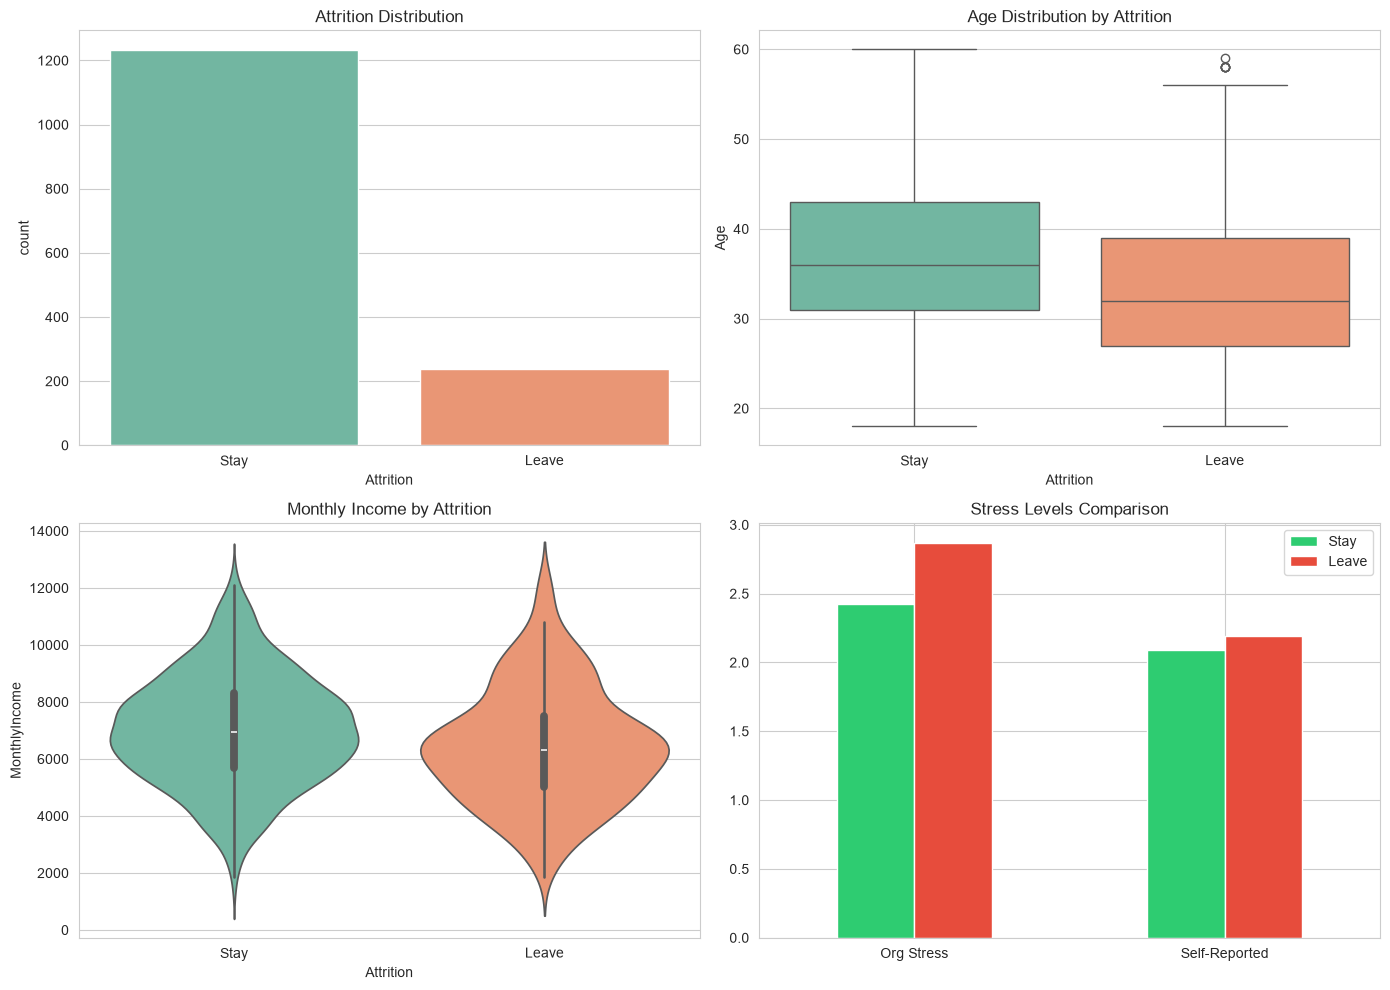

09:13:32 | INFO     | Top correlations with Attrition:
09:13:32 | INFO     |   StressRating                  : +0.184 (increases attrition risk)
09:13:32 | INFO     |   DistanceFromHome              : +0.075 (increases attrition risk)
09:13:32 | INFO     |   NumCompaniesWorked            : +0.058 (increases attrition risk)
09:13:32 | INFO     |   StressSelfReported            : +0.039 (increases attrition risk)
09:13:32 | INFO     |   OverTime                      : +0.038 (increases attrition risk)
09:13:32 | INFO     | Top attrition rates by OverTime (n >= 20):
09:13:32 | INFO     |     (27.0, 61.0]: 19.5% (n=282)
09:13:32 | INFO     |     (3.0, 9.0]: 17.3% (n=306)
09:13:32 | INFO     |     (17.0, 27.0]: 16.5% (n=285)
09:13:32 | INFO     | Top attrition rates by JobRole (n >= 20):
09:13:32 | INFO     |     Sales Representative: 37.8% (n=82)
09:13:32 | INFO     |     Laboratory Technician: 26.6% (n=259)
09:13:32 | INFO     |     Human Resources: 23.1% (n=52)
09:13:32 | INFO     | Top 

,Correlation with Attrition
Attrition,1.000000
StressRating,0.184437
DistanceFromHome,0.074684
NumCompaniesWorked,0.058003
StressSelfReported,0.039347
OverTime,0.037973
Year,0.011080
MonthlyAchievement,0.000276
PerformanceIndex,-0.014094
PerformanceRating,-0.029690


In [52]:
correlation_summary = perform_comprehensive_eda(df, ARTIFACTS_PATH)
correlation_summary.head(10).to_frame("Correlation with Attrition")

### 💡 Business Insights & Next Steps — EDA

- **Stress is the strongest measured driver, but it's not a huge signal.** `StressRating` has the highest correlation with attrition among numeric features (+0.18), ahead of `DistanceFromHome` (+0.07) and `NumCompaniesWorked` (+0.06). None of these are strong on their own, so attrition here is probably driven by a combination of things rather than one dominant variable. Which is basically why the SHAP analysis in Section 8 (per-employee, multi-factor) is more useful than this ranking by itself.
- **Role and marital status show a much wider spread.** Sales Representatives leave at 37.8%, more than double the Married rate (13.7%) and almost 4x the Divorced rate (9.7%). Single employees leave at 24.4%, almost double the Married rate. Bigger effect sizes than anything in the correlation table.
- **Leavers earn less on average.** $6,453/month vs $7,013/month for stayers (~8% gap). Fits the role/stress pattern: lower-paid, higher-stress, higher-turnover roles look like a distinct risk segment rather than a random slice of the workforce.
- **What this means for retention:** the risk looks role-level (Sales Rep, Lab Technician), not company-wide. Worth checking in Section 9/10 whether the model's High/Critical tier is mostly these roles, since that would justify a targeted pilot instead of rolling this out everywhere.

## 4. Feature Engineering & Preprocessing Pipeline

In [53]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive a handful of features from the raw columns.

    New columns:
        - tenure_bins: tenure bucket
        - stress_gap: self-reported minus organizational stress
        - income_per_year: income normalized by working experience
        - overtime_x_stress: overtime * stress interaction
        - satisfaction_score: average of 3 satisfaction measures
        - age_group: age bucket
        - underperform_stressed: flag for low performance + high stress

    Args:
        df: Cleaned HR DataFrame.

    Returns:
        Same DataFrame plus the columns above.
    """
    df_fe = df.copy()

    df_fe["tenure_bins"] = pd.cut(
        df_fe["YearsAtCompany"], bins=[0, 2, 5, 10, 100],
        labels=["0-2yr", "2-5yr", "5-10yr", "10+yr"],
    )
    df_fe["stress_gap"] = df_fe["StressSelfReported"] - df_fe["StressRating"]
    df_fe["income_per_year"] = df_fe["MonthlyIncome"] / (df_fe["TotalWorkingYears"] + 1)
    df_fe["overtime_x_stress"] = df_fe["OverTime"] * df_fe["StressRating"]
    df_fe["satisfaction_score"] = (
        df_fe["JobSatisfaction"] + df_fe["EnvironmentSatisfaction"] + df_fe["RelationshipSatisfaction"]
    ) / 3
    df_fe["age_group"] = pd.cut(
        df_fe["Age"], bins=[0, 30, 40, 50, 100], labels=["<30", "30-40", "40-50", "50+"]
    )
    df_fe["underperform_stressed"] = (
        (df_fe["PerformanceRating"] < 3) & (df_fe["StressRating"] >= 3)
    ).astype(int)

    return df_fe


def build_preprocessing_pipeline(
    X: pd.DataFrame, scale_numeric: bool = True
) -> Tuple[ColumnTransformer, List[str], List[str]]:
    """
    Build the sklearn preprocessing pipeline: median-impute (+ optional
    robust-scale) for numeric, constant-impute + one-hot for categorical.

    Args:
        X: Training feature matrix (target already removed). Only used to
           detect column dtypes here, fitting happens where this is called
           so nothing gets learned from the test set.
        scale_numeric: Whether to RobustScaler the numeric features.
            Logistic Regression needs it (scale-sensitive), LightGBM
            doesn't (tree splits are invariant to monotonic transforms,
            so scaling is just an extra step that also makes SHAP/business
            output harder to read in original units). Set False for the
            LightGBM path (Section 6 onward).

    Returns:
        (unfitted ColumnTransformer, numeric_features, categorical_features)
    """
    # exclude=[np.number] instead of include=["object", "category"]: pandas >= 3.0 stores
    # text as a "str" dtype, not "object", so an include-list keyed on "object" misses it
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", RobustScaler()))
    numeric_transformer = Pipeline(steps=numeric_steps)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
    ])
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])
    preprocessor.set_output(transform="pandas")

    scale_note = "median impute + robust scale" if scale_numeric else "median impute only, no scaling"
    logger.info(
        f"Preprocessing pipeline: {len(numeric_features)} numeric features "
        f"({scale_note}), {len(categorical_features)} categorical features (one-hot)"
    )
    return preprocessor, numeric_features, categorical_features

In [54]:
df_fe = engineer_features(df)

X_raw = df_fe.drop(columns=["Attrition"])
y = df_fe["Attrition"]

#split before fitting any preprocessing stats so nothing leaks from test into train
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# two versions of the same split: scaled for LR, unscaled for LightGBM (see build_preprocessing_pipeline)
preprocessor, numeric_features, categorical_features = build_preprocessing_pipeline(X_train_raw, scale_numeric=True)
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

preprocessor_tree, _, _ = build_preprocessing_pipeline(X_train_raw, scale_numeric=False)
X_train_tree = preprocessor_tree.fit_transform(X_train_raw)
X_test_tree = preprocessor_tree.transform(X_test_raw)

logger.info(f"Final training matrix (scaled, LR): {X_train.shape}, test matrix: {X_test.shape}")
logger.info(f"Final training matrix (unscaled, LightGBM): {X_train_tree.shape}, test matrix: {X_test_tree.shape}")
X_train.head()

09:13:32 | INFO     | Preprocessing pipeline: 37 numeric features (median impute + robust scale), 9 categorical features (one-hot)
09:13:32 | INFO     | Preprocessing pipeline: 37 numeric features (median impute only, no scaling), 9 categorical features (one-hot)
09:13:32 | INFO     | Final training matrix (scaled, LR): (1176, 69), test matrix: (294, 69)
09:13:32 | INFO     | Final training matrix (unscaled, LightGBM): (1176, 69), test matrix: (294, 69)


,num__Age,num__DistanceFromHome,num__Education,num__EnvironmentSatisfaction,num__PerformanceIndex,num__JobInvolvement,num__JobLevel,num__JobSatisfaction,num__MonthlyAchievement,num__NumCompaniesWorked,...,cat__HowToEmploy_agent_C,cat__HowToEmploy_direct_recruiting,cat__HowToEmploy_intern,cat__tenure_bins_10+yr,cat__tenure_bins_2-5yr,cat__tenure_bins_5-10yr,cat__tenure_bins_missing,cat__age_group_40-50,cat__age_group_50+,cat__age_group_<30
517,-0.846154,0.076923,0.0,0.5,-0.250000,1.0,0.0,-0.5,0.110722,-0.666667,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
317,1.230769,0.076923,0.5,0.0,0.527778,-1.0,0.0,-0.5,0.275589,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
78,0.076923,0.000000,0.5,-1.0,-1.000000,0.0,0.5,0.0,0.874099,0.666667,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1287,0.461538,0.461538,0.0,-0.5,0.805556,1.0,0.0,-1.0,-0.684689,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
299,1.153846,-0.384615,0.0,0.5,0.500000,-2.0,0.0,-0.5,0.161959,1.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 5. Baseline Model — Logistic Regression

Quick baseline before jumping to something fancier. If LightGBM can't clearly beat plain Logistic Regression, the extra complexity isn't worth it.

In [55]:
def run_cross_validation(
    model, X: pd.DataFrame, y: pd.Series, cv_folds: int = CV_FOLDS, random_state: int = RANDOM_STATE
) -> pd.DataFrame:
    """Stratified k-fold CV, returns AUC/Precision/Recall/F1 (test mean/std, train mean)."""
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    scoring = {"auc": "roc_auc", "precision": "precision", "recall": "recall", "f1": "f1"}
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=True)

    rows = [
        {
            "metric": metric.upper(),
            "test_mean": cv_results[f"test_{metric}"].mean(),
            "test_std": cv_results[f"test_{metric}"].std(),
            "train_mean": cv_results[f"train_{metric}"].mean(),
        }
        for metric in ["auc", "precision", "recall", "f1"]
    ]
    return pd.DataFrame(rows)


def train_baseline_model(
    X_train: pd.DataFrame, X_test: pd.DataFrame, y_train: pd.Series, y_test: pd.Series
) -> Tuple[LogisticRegression, Dict[str, float]]:
    """Fits a Logistic Regression baseline, returns (model, test metrics dict)."""
    baseline_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
    baseline_model.fit(X_train, y_train)

    y_prob = baseline_model.predict_proba(X_test)[:, 1]
    y_pred = baseline_model.predict(X_test)
    metrics = {
        "AUC-ROC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    }
    logger.info(f"Baseline test AUC-ROC: {metrics['AUC-ROC']:.4f}")
    return baseline_model, metrics

In [56]:
baseline_cv_summary = run_cross_validation(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    X_train, y_train,
)
display(baseline_cv_summary)

baseline_model, baseline_test_metrics = train_baseline_model(X_train, X_test, y_train, y_test)
pd.Series(baseline_test_metrics, name="Baseline (Logistic Regression)").to_frame()

,metric,test_mean,test_std,train_mean
0,AUC,0.812484,0.017797,0.894196
1,PRECISION,0.400370,0.022141,0.448049
2,RECALL,0.731579,0.060925,0.825000
3,F1,0.515754,0.017544,0.580676


09:13:32 | INFO     | Baseline test AUC-ROC: 0.8384


,Baseline (Logistic Regression)
AUC-ROC,0.838415
Precision,0.391304
Recall,0.750000
F1-Score,0.514286


## 6. Model Training — LightGBM with Hyperparameter Optimization

LightGBM should do better here since it can pick up non-linear interactions (like `overtime_x_stress`) and handles the imbalance natively through `class_weight="balanced"`. Trees don't care about feature scaling (split points don't change under a monotonic transform), so from here on we use `X_train_tree`/`X_test_tree` instead of the scaled matrices from the baseline. Bonus: keeps SHAP output in Section 8 closer to raw units.

Instead of hand-picking hyperparameters we run a quick [Optuna](https://optuna.org/) search (`OPTUNA_N_TRIALS` trials, Section 1) maximizing mean CV AUC-ROC.

In [57]:
def optimize_lightgbm(X_train: pd.DataFrame, y_train: pd.Series, n_trials: int = OPTUNA_N_TRIALS) -> optuna.study.Study:
    """
    Optuna search over LightGBM hyperparameters, maximizing mean CV AUC-ROC,
    with early stopping inside each fold.

    Each trial sets a high n_estimators ceiling and lets early stopping on
    that fold's validation slice pick the real number of rounds, instead of
    Optuna picking one fixed n_estimators that fits identically (and often
    too far) on every fold. Search space is also tighter than a first naive
    pass: max_depth capped at 6 (was 10), higher regularization floors (was
    reg_alpha >= 1e-3). The wider space kept driving training metrics to a
    perfect 1.0.

    Args:
        X_train: Preprocessed (unscaled) training features.
        y_train: Training target.
        n_trials: Number of Optuna trials.

    Returns:
        The finished Optuna study (study.best_params has the winner).
    """
    cv = StratifiedKFold(n_splits=OPTUNA_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial: optuna.trial.Trial) -> float:
        params = {
            "n_estimators": 2000,  #ceiling only, early stopping picks the real count per fold
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63),
            "max_depth": trial.suggest_int("max_depth", 3, 6),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 50.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 50.0, log=True),
            "class_weight": "balanced",
            "random_state": RANDOM_STATE,
            "verbosity": -1,
        }
        fold_aucs = []
        for train_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            model = lgb.LGBMClassifier(**params)
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                eval_metric="auc",
                callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)],
            )
            fold_aucs.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
        return float(np.mean(fold_aucs))

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE), study_name="lgbm_attrition_tuning")
    study.optimize(objective, n_trials=n_trials, timeout=OPTUNA_TIMEOUT_SECONDS, show_progress_bar=True)

    logger.info(f"Optuna best CV AUC-ROC (early-stopped): {study.best_value:.4f}")
    logger.info(f"Optuna best params: {study.best_params}")
    return study

In [58]:
study = optimize_lightgbm(X_train_tree, y_train, n_trials=OPTUNA_N_TRIALS)

# pick n_estimators via early stopping on a slice of X_train (not X_test), then refit on
# the full X_train at that count so the final model isn't wasting rows on validation
X_fit, X_val_final, y_fit, y_val_final = train_test_split(
    X_train_tree, y_train, test_size=FINAL_VALIDATION_SIZE, random_state=RANDOM_STATE, stratify=y_train
)
probe_params = {**study.best_params, "n_estimators": 2000, "class_weight": "balanced", "random_state": RANDOM_STATE, "verbosity": -1}
probe_model = lgb.LGBMClassifier(**probe_params)
probe_model.fit(
    X_fit, y_fit,
    eval_set=[(X_val_final, y_val_final)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)],
)
logger.info(f"Early stopping picked n_estimators = {probe_model.best_iteration_} (ceiling was 2000)")

best_params = {
    **study.best_params,
    "n_estimators": probe_model.best_iteration_,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "verbosity": -1,
}
final_model = lgb.LGBMClassifier(**best_params)

lgbm_cv_summary = run_cross_validation(final_model, X_train_tree, y_train)
display(lgbm_cv_summary)

final_model.fit(X_train_tree, y_train)

  0%|          | 0/30 [00:00<?, ?it/s]

09:13:40 | INFO     | Optuna best CV AUC-ROC (early-stopped): 0.8412
09:13:40 | INFO     | Optuna best params: {'learning_rate': 0.14957505138098018, 'num_leaves': 16, 'max_depth': 6, 'min_child_samples': 67, 'subsample': 0.7909618537318432, 'colsample_bytree': 0.9366012437097202, 'reg_alpha': 0.05184558147234691, 'reg_lambda': 38.485763686213666}
09:13:40 | INFO     | Early stopping picked n_estimators = 120 (ceiling was 2000)


,metric,test_mean,test_std,train_mean
0,AUC,0.835459,0.025702,0.988083
1,PRECISION,0.488143,0.038575,0.706801
2,RECALL,0.636842,0.045275,0.967105
3,F1,0.550457,0.022174,0.816704


,num_leaves,16
,max_depth,6
,learning_rate,0.14957505138098018
,n_estimators,120
,class_weight,'balanced'
,min_child_samples,67
,subsample,0.7909618537318432
,colsample_bytree,0.9366012437097202
,reg_alpha,0.05184558147234691
,reg_lambda,38.485763686213666
,random_state,42


,Logistic Regression (Baseline),LightGBM (Tuned)
metric,,
AUC,0.8125,0.8355
PRECISION,0.4004,0.4881
RECALL,0.7316,0.6368
F1,0.5158,0.5505


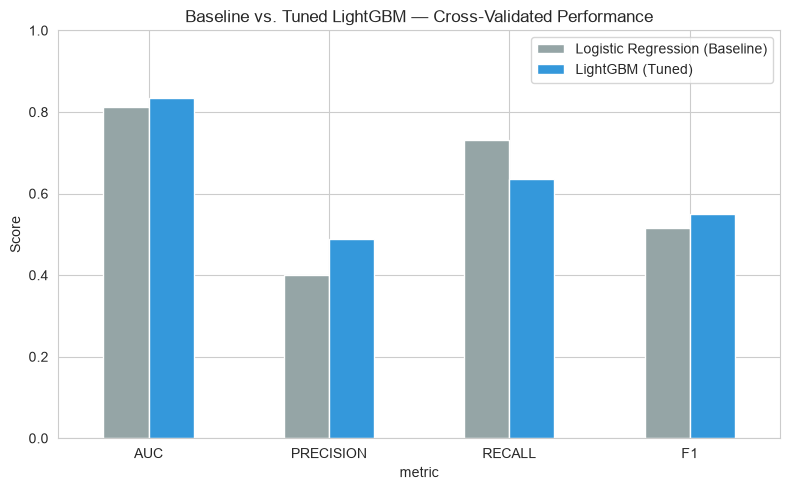

In [59]:
#baseline vs tuned LightGBM, cross-validated
comparison_df = pd.DataFrame({
    "Logistic Regression (Baseline)": baseline_cv_summary.set_index("metric")["test_mean"],
    "LightGBM (Tuned)": lgbm_cv_summary.set_index("metric")["test_mean"],
})
display(comparison_df.style.format("{:.4f}"))

comparison_df.plot(kind="bar", figsize=(8, 5), color=["#95a5a6", "#3498db"])
plt.title("Baseline vs. Tuned LightGBM — Cross-Validated Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / "model_comparison.png", dpi=150)
plt.show()
plt.close()

## 7. Threshold Optimization (Precision-Recall Curve)

0.5 doesn't make sense as a cutoff here. With a ~5:1 imbalance (Section 3), a model that's just barely above 50% confident on the minority class gets rounded down to "stay", so real leavers slip through. We scan the Precision-Recall curve instead, using out-of-fold predictions from the training set only (never the test set, otherwise we'd be tuning the threshold on the same data we use to report the final score) and pick whatever maximizes F1.

In [60]:
def find_optimal_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> Tuple[float, Dict[str, float]]:
    """Scans the PR curve, returns the threshold that maximizes F1 plus precision/recall/f1 at that point."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = np.divide(
        2 * precision * recall, precision + recall,
        out=np.zeros_like(precision), where=(precision + recall) > 0,
    )
    f1_scores, precision, recall = f1_scores[:-1], precision[:-1], recall[:-1]

    best_idx = int(np.argmax(f1_scores))
    best_threshold = float(thresholds[best_idx])
    details = {
        "precision": float(precision[best_idx]),
        "recall": float(recall[best_idx]),
        "f1": float(f1_scores[best_idx]),
    }
    return best_threshold, details


def plot_threshold_curve(y_true: np.ndarray, y_prob: np.ndarray, chosen_threshold: float, save_path: Path) -> None:
    """Plots precision/recall/F1 vs threshold, marks the chosen cutoff against the default 0.5."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = np.divide(
        2 * precision * recall, precision + recall,
        out=np.zeros_like(precision), where=(precision + recall) > 0,
    )
    plt.figure(figsize=(9, 5))
    plt.plot(thresholds, precision[:-1], label="Precision")
    plt.plot(thresholds, recall[:-1], label="Recall")
    plt.plot(thresholds, f1_scores[:-1], label="F1-Score")
    plt.axvline(chosen_threshold, color="black", linestyle="--", label=f"Selected threshold = {chosen_threshold:.2f}")
    plt.axvline(0.5, color="gray", linestyle=":", label="Default 0.5")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title("Threshold Selection — Precision / Recall / F1 Trade-off")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

09:13:41 | INFO     | Optimal threshold (out-of-fold, F1-maximizing): 0.554
09:13:41 | INFO     | Precision 0.556, Recall 0.600, F1 0.577 at that threshold


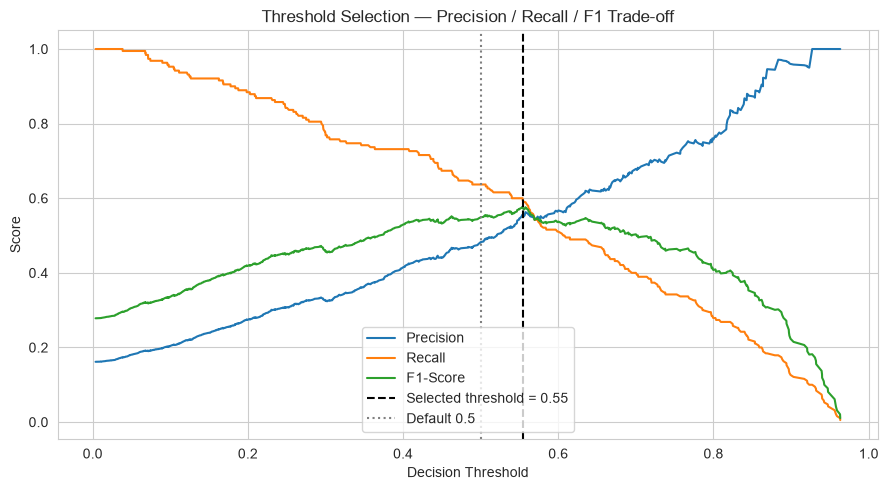

In [61]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_probs = cross_val_predict(final_model, X_train_tree, y_train, cv=cv, method="predict_proba")[:, 1]

optimal_threshold, threshold_details = find_optimal_threshold(y_train.values, oof_probs)
logger.info(f"Optimal threshold (out-of-fold, F1-maximizing): {optimal_threshold:.3f}")
logger.info(
    f"Precision {threshold_details['precision']:.3f}, "
    f"Recall {threshold_details['recall']:.3f}, F1 {threshold_details['f1']:.3f} at that threshold"
)

plot_threshold_curve(y_train.values, oof_probs, optimal_threshold, ARTIFACTS_PATH / "threshold_selection.png")

In [62]:
# threshold came from out-of-fold predictions on train, so this test-set check is clean
y_prob_test = final_model.predict_proba(X_test_tree)[:, 1]
y_pred_test = (y_prob_test >= optimal_threshold).astype(int)

test_metrics = {
    "AUC-ROC": roc_auc_score(y_test, y_prob_test),
    "Precision": precision_score(y_test, y_pred_test),
    "Recall": recall_score(y_test, y_pred_test),
    "F1-Score": f1_score(y_test, y_pred_test),
}
logger.info("Final LightGBM test performance, optimized threshold:")
for name, value in test_metrics.items():
    logger.info(f"  {name:12s}: {value:.4f}")

print(classification_report(y_test, y_pred_test, target_names=["Stay", "Leave"]))

09:13:41 | INFO     | Final LightGBM test performance, optimized threshold:
09:13:41 | INFO     |   AUC-ROC     : 0.8288
09:13:41 | INFO     |   Precision   : 0.4655
09:13:41 | INFO     |   Recall      : 0.5625
09:13:41 | INFO     |   F1-Score    : 0.5094


              precision    recall  f1-score   support

        Stay       0.91      0.87      0.89       246
       Leave       0.47      0.56      0.51        48

    accuracy                           0.82       294
   macro avg       0.69      0.72      0.70       294
weighted avg       0.84      0.82      0.83       294



## 8. Model Explainability — SHAP

In [63]:
def explain_with_shap(
    model: lgb.LGBMClassifier, X_test: pd.DataFrame, artifacts_dir: Path
) -> Tuple[shap.TreeExplainer, np.ndarray]:
    """Computes SHAP values for the LightGBM model, saves the global importance + summary plots."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    shap_values_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_class1, X_test, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Global)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(artifacts_dir / "shap_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_class1, X_test, show=False)
    plt.title("SHAP Summary Plot (Feature Impact)", fontsize=14)
    plt.tight_layout()
    plt.savefig(artifacts_dir / "shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    return explainer, shap_values_class1

def build_display_names(feature_names: pd.Index) -> List[str]:
    """Strips the ColumnTransformer's num__/cat__ prefixes so SHAP output is readable."""
    clean = []
    for name in feature_names:
        if name.startswith("num__"):
            clean.append(name.removeprefix("num__"))
        elif name.startswith("cat__"):
            clean.append(name.removeprefix("cat__").replace("_", ": ", 1))
        else:
            clean.append(name)
    return clean


def build_display_values(feature_names: pd.Index, employee_index, X_test: pd.DataFrame, X_test_raw: pd.DataFrame) -> np.ndarray:
    """Numeric columns come from X_test_raw (original units), categorical ones stay 0/1."""
    transformed_row = X_test.loc[employee_index].values
    display_vals = []
    for name, transformed_val in zip(feature_names, transformed_row):
        if name.startswith("num__"):
            raw_col = name.removeprefix("num__")
            display_vals.append(X_test_raw.loc[employee_index, raw_col])
        else:
            display_vals.append(transformed_val)
    return np.array(display_vals, dtype=float)


def explain_single_employee(
    model, explainer, shap_values_class1, X_test, X_test_raw, artifacts_dir, employee_index=None
) -> None:
    probs = model.predict_proba(X_test)[:, 1]
    if employee_index is None:
        employee_index = X_test.index[np.argmax(probs)]

    row_pos = X_test.index.get_loc(employee_index)
    prob = model.predict_proba(X_test.loc[[employee_index]])[0][1]

    shap_vals_employee = shap_values_class1[row_pos]
    feature_names = X_test.columns
    display_names = build_display_names(feature_names)
    display_values = build_display_values(feature_names, employee_index, X_test, X_test_raw)
    top_indices = np.argsort(np.abs(shap_vals_employee))[-5:][::-1]

    print(f"HIGH-RISK EMPLOYEE (index {employee_index}), attrition probability {prob:.2%}")
    print("Top 5 contributing factors:")
    for rank, idx in enumerate(top_indices, 1):
        feat_display, feat_val, shap_val = display_names[idx], display_values[idx], shap_vals_employee[idx]
        direction = "INCREASES" if shap_val > 0 else "DECREASES"
        print(f"  {rank}. {feat_display:30s} = {feat_val:8.2f}  (SHAP: {shap_val:+.3f})  {direction} risk")

    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)) and np.ndim(base_value) > 0 and len(base_value) > 1:
        base_value = base_value[1]

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals_employee,
            base_values=base_value,
            data=display_values,          #raw units, not scaled/transformed
            feature_names=display_names,  #readable names, not raw ColumnTransformer output
        ),
        show=False,
    )
    plt.title(f"SHAP Waterfall — Employee {employee_index}", fontsize=14)
    plt.tight_layout()
    plt.savefig(artifacts_dir / "shap_waterfall_example.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

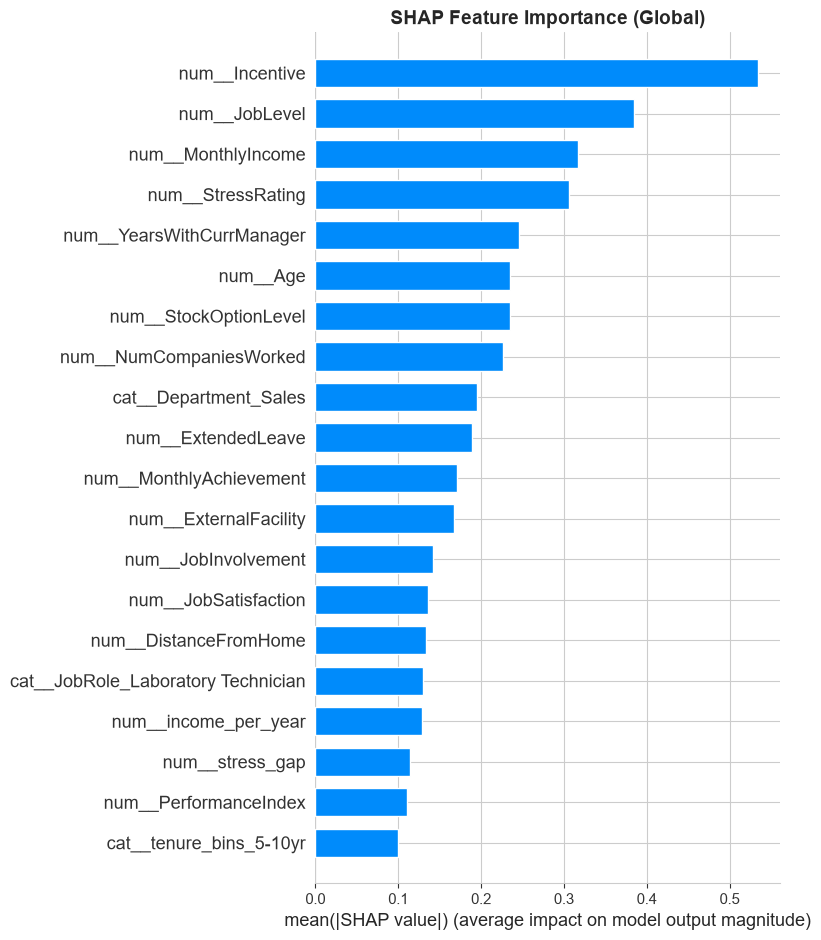

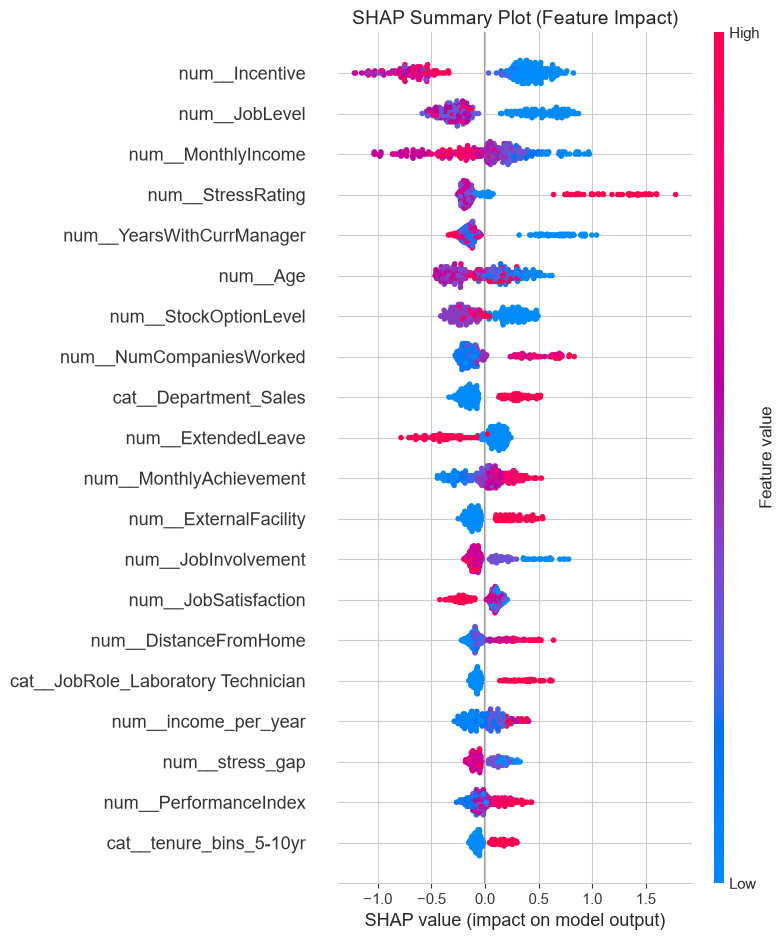

HIGH-RISK EMPLOYEE (index 1379), attrition probability 97.93%
Top 5 contributing factors:
  1. Incentive                      =     0.00  (SHAP: +0.656)  INCREASES risk
  2. StressRating                   =     4.00  (SHAP: +0.640)  INCREASES risk
  3. YearsWithCurrManager           =     0.00  (SHAP: +0.617)  INCREASES risk
  4. JobLevel                       =     1.00  (SHAP: +0.454)  INCREASES risk
  5. Age                            =    27.00  (SHAP: +0.390)  INCREASES risk


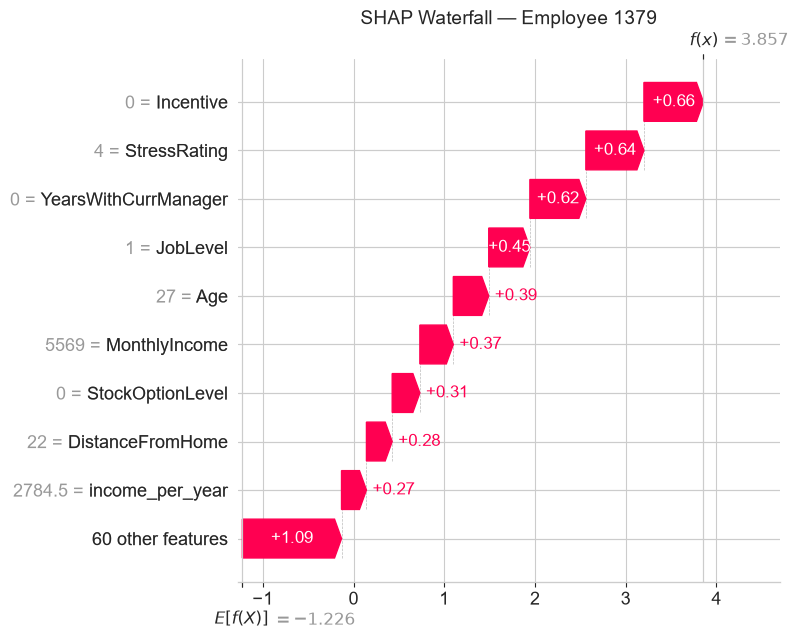

In [64]:
explainer, shap_values_class1 = explain_with_shap(final_model, X_test_tree, ARTIFACTS_PATH)
explain_single_employee(final_model, explainer, shap_values_class1, X_test_tree, X_test_raw, ARTIFACTS_PATH)

### 💡 Business Insights & Next Steps — SHAP

- **Top driver that shows up twice:** `StressRating` is the one factor that's prominent in both the correlation ranking (Section 3, strongest numeric correlate at +0.18) and the SHAP breakdown below (#2 for this employee). Two different methods agreeing is a decent sign this isn't just a modeling artifact.
- **What SHAP catches that correlation missed:** top driver for this employee is `Incentive = 0.00` (no incentive pay), then `YearsWithCurrManager = 0.00` (brand new manager relationship). Neither showed up high in the plain correlation table. This is basically the whole point of SHAP over Section 3: it picks up interaction-driven, per-employee factors that a single global correlation number just averages away.
- **What HR could actually do here (employee's at 97.9% predicted risk):** young (Age 27), entry-level (`JobLevel=1`), high stress, no incentive pay, brand new to their manager. A check-in plus looking at whether a bonus is overdue hits the two things that are actually fixable (`Incentive`, `YearsWithCurrManager`), as opposed to `Age`/`JobLevel` which nobody can do much about.
- **Worth tracking going forward:** if `Incentive=0` and low `YearsWithCurrManager` keep showing up across the wider High Risk tier (would need a SHAP summary plot over that whole group, not just one employee), that's a cheap fix, comp timing and manager transitions, unlike age or job level which the company just can't change.

## 9. Risk Segmentation

In [65]:
def segment_risk(X_test: pd.DataFrame, y_test: pd.Series, y_prob: np.ndarray, threshold: float) -> pd.DataFrame:
    results_df = X_test.copy()
    results_df["True_Attrition"] = y_test
    results_df["Probability"] = y_prob
    results_df["Prediction"] = (y_prob >= threshold).astype(int)

    bins, labels = build_risk_bins(threshold)  # anchored to the model's threshold, not fixed numbers
    results_df["Risk_Category"] = pd.cut(
        results_df["Probability"], bins=bins, labels=labels, right=True, include_lowest=True
    )

    logger.info(f"Risk bins (threshold={threshold:.3f}): {bins}")
    logger.info(f"\n{results_df['Risk_Category'].value_counts()}")
    return results_df

In [66]:
results_df = segment_risk(X_test_tree, y_test, y_prob_test, optimal_threshold)
results_df["Risk_Category"].value_counts().to_frame("Employee Count")
print(pd.crosstab(results_df["Prediction"], results_df["Risk_Category"]))

09:13:44 | INFO     | Risk bins (threshold=0.554): [0.0, 0.5539820666308709, 0.7026547110872473, 0.8513273555436236, 1.0]
09:13:44 | INFO     | 
Risk_Category
Low Risk                  236
Medium Risk                25
High Risk                  21
Flight Risk (Critical)     12
Name: count, dtype: int64


Risk_Category  Low Risk  Medium Risk  High Risk  Flight Risk (Critical)
Prediction                                                             
0                   236            0          0                       0
1                     0           25         21                      12


## 10. Business Impact Simulation (ROI)

Costing out a **"Targeted Retention Program"** (stay interviews + market-rate salary bumps) for every employee the model's threshold flags as attrition-likely (`Medium Risk`, `High Risk`, `Flight Risk (Critical)`, see Section 9). All the dollar assumptions live in `CONFIG` (Section 1) so a CFO can just change a number and rerun.

`INTERVENTION_EFFECTIVENESS` (20%) is a guess, honestly. Company I doesn't have historical data on a program like this to calibrate against. So instead of betting everything on one number we show Net ROI across 10/20/30% effectiveness plus the break-even point.

In [67]:
def simulate_roi(
    results_df: pd.DataFrame,
    df_original: pd.DataFrame,
    effectiveness: float = INTERVENTION_EFFECTIVENESS,
    replacement_cost_multiplier: float = REPLACEMENT_COST_MULTIPLIER,
    verbose: bool = True,
) -> Dict[str, float]:
    """Quantify the retention program's financial case for the Medium/High/
    Flight Risk (Critical) tiers (everyone the F1-optimal threshold flags
    as attrition-likely).

    Model:
        Baseline Loss  = sum(P(leave) * replacement_cost) for the target group
        New Loss       = sum(P(leave) * (1 - effectiveness) * replacement_cost)
        Program Cost   = INTERVENTION_COST_PER_EMPLOYEE * target group size
        Net ROI        = (Baseline Loss - New Loss) - Program Cost
        Break-even eff = Program Cost / Baseline Loss (savings are linear in
                         effectiveness so this has a closed form, no need to
                         search for it)

    Args:
        results_df: Output of segment_risk (needs Risk_Category and
            Probability columns, indexed like df_original).
        df_original: Cleaned source DataFrame, for the MonthlyIncome lookup.
        effectiveness: Assumed reduction in attrition probability after
            intervention. Defaults to CONFIG; override for a sensitivity
            table (see roi_sensitivity_table).
        replacement_cost_multiplier: Replacement cost as a fraction of
            annual salary. Defaults to CONFIG; override for a sensitivity
            table (see roi_sensitivity_table_by_replacement_cost).
        verbose: Print the formatted report or not. False when called in a loop.

    Returns:
        Dict with the full breakdown, or {} if no high-risk employees in test set.
    """
    results_df = results_df.copy()
    results_df["MonthlyIncome"] = df_original.loc[results_df.index, "MonthlyIncome"]

    TARGET_CATEGORIES = ["Medium Risk", "High Risk", "Flight Risk (Critical)"]  #everyone Prediction=1 flags
    target_group = results_df[results_df["Risk_Category"].isin(TARGET_CATEGORIES)]
    if len(target_group) == 0:
        logger.warning("No high-risk employees in the test set, skipping ROI simulation")
        return {}

    annual_salary = target_group["MonthlyIncome"] * 12
    replacement_cost = annual_salary * replacement_cost_multiplier

    baseline_loss = float((target_group["Probability"] * replacement_cost).sum())
    intervention_cost = INTERVENTION_COST_PER_EMPLOYEE * len(target_group)
    reduced_probs = target_group["Probability"] * (1 - effectiveness)
    new_loss = float((reduced_probs * replacement_cost).sum())

    savings = baseline_loss - new_loss
    net_roi = savings - intervention_cost
    roi_pct = (net_roi / intervention_cost) * 100 if intervention_cost else float("nan")
    break_even_effectiveness = (intervention_cost / baseline_loss) if baseline_loss else float("nan")

    report = {
        "effectiveness": effectiveness,
        "replacement_cost_multiplier": replacement_cost_multiplier,
        "target_group_size": len(target_group),
        "baseline_loss": baseline_loss,
        "new_loss": new_loss,
        "gross_savings": savings,
        "program_cost": intervention_cost,
        "net_roi": net_roi,
        "roi_pct": roi_pct,
        "break_even_effectiveness": break_even_effectiveness,
    }

    if verbose:
        print("---")
        print("PROPOSED STRATEGY: 'Targeted Retention Program'")
        print("---")
        print(f"Target Scope:          {report['target_group_size']} employees (Medium/High/Critical Risk)")
        print(f"Assumed Effectiveness: {effectiveness:.0%}")
        print(f"Replacement Cost:      {replacement_cost_multiplier:.0%} of annual salary")
        print(f"Baseline Loss:         ${report['baseline_loss']:,.2f}")
        print(f"New Projected Loss:    ${report['new_loss']:,.2f}")
        print(f"Gross Savings:         ${report['gross_savings']:,.2f}")
        print(f"Program Cost:          ${report['program_cost']:,.2f}")
        print(f"NET ROI:               ${report['net_roi']:,.2f} ({report['roi_pct']:.1f}%)")
        print(f"Break-even effectiveness: {report['break_even_effectiveness']:.1%} "
              f"(program pays for itself above this)")
        print("---")

    return report


def roi_sensitivity_table(
    results_df: pd.DataFrame,
    df_original: pd.DataFrame,
    effectiveness_levels: List[float] = [0.10, 0.20, 0.30],
) -> pd.DataFrame:
    """Net ROI across a range of effectiveness assumptions, since 20% is just an estimate."""
    rows = []
    for eff in effectiveness_levels:
        report = simulate_roi(results_df, df_original, effectiveness=eff, verbose=False)
        rows.append({
            "Effectiveness": f"{eff:.0%}",
            "Gross Savings ($)": report["gross_savings"],
            "Net ROI ($)": report["net_roi"],
            "ROI (%)": report["roi_pct"],
        })
    return pd.DataFrame(rows)


def roi_sensitivity_table_by_replacement_cost(
    results_df: pd.DataFrame,
    df_original: pd.DataFrame,
    multiplier_levels: List[float] = [0.5, 1.0, 1.5, 2.0],
) -> pd.DataFrame:
    """Net ROI across the published 50%-200% replacement-cost range, since 150% is an external benchmark."""
    rows = []
    for mult in multiplier_levels:
        report = simulate_roi(results_df, df_original, replacement_cost_multiplier=mult, verbose=False)
        rows.append({
            "Replacement Cost": f"{mult:.0%} of salary",
            "Gross Savings ($)": report["gross_savings"],
            "Net ROI ($)": report["net_roi"],
            "ROI (%)": report["roi_pct"],
        })
    return pd.DataFrame(rows)

In [68]:
roi_report = simulate_roi(results_df, df)

---
PROPOSED STRATEGY: 'Targeted Retention Program'
---
Target Scope:          58 employees (Medium/High/Critical Risk)
Assumed Effectiveness: 20%
Replacement Cost:      150% of annual salary
Baseline Loss:         $4,922,035.19
New Projected Loss:    $3,937,628.16
Gross Savings:         $984,407.04
Program Cost:          $174,000.00
NET ROI:               $810,407.04 (465.8%)
Break-even effectiveness: 3.5% (program pays for itself above this)
---


In [69]:
# Net ROI depends a lot on INTERVENTION_EFFECTIVENESS, which is unvalidated. showing a range instead of one point estimate.
sensitivity_df = roi_sensitivity_table(results_df, df)
display(
    sensitivity_df.style.format({
        "Gross Savings ($)": "${:,.0f}",
        "Net ROI ($)": "${:,.0f}",
        "ROI (%)": "{:.1f}%",
    })
)
print(
    f"\nBreaks even above {roi_report['break_even_effectiveness']:.1%} effectiveness, "
    f"comfortably below the {INTERVENTION_EFFECTIVENESS:.0%} base case."
)

,Effectiveness,Gross Savings ($),Net ROI ($),ROI (%)
0,10%,"$492,204","$318,204",182.9%
1,20%,"$984,407","$810,407",465.8%
2,30%,"$1,476,611","$1,302,611",748.6%



Breaks even above 3.5% effectiveness, comfortably below the 20% base case.


In [70]:
#REPLACEMENT_COST_MULTIPLIER (150%) is an external benchmark, not something measured from
#Company I's own hiring costs, so showing the 50%-200% published range too.
cost_sensitivity_df = roi_sensitivity_table_by_replacement_cost(results_df, df)
display(
    cost_sensitivity_df.style.format({
        "Gross Savings ($)": "${:,.0f}",
        "Net ROI ($)": "${:,.0f}",
        "ROI (%)": "{:.1f}%",
    })
)

,Replacement Cost,Gross Savings ($),Net ROI ($),ROI (%)
0,50% of salary,"$328,136","$154,136",88.6%
1,100% of salary,"$656,271","$482,271",277.2%
2,150% of salary,"$984,407","$810,407",465.8%
3,200% of salary,"$1,312,543","$1,138,543",654.3%


In [71]:
print("---")
print("EXECUTIVE RECAP, copy into the Executive Summary above")
print("---")
print("Best Model:              LightGBM (Optuna-tuned)")
print(f"Test AUC-ROC:            {test_metrics['AUC-ROC']:.4f}")
print(f"Test F1-Score:           {test_metrics['F1-Score']:.4f}")
print(f"Optimal Threshold:       {optimal_threshold:.3f}  (vs. default 0.50)")
if roi_report:
    print(f"Retention Program Cost:  ${roi_report['program_cost']:,.2f}")
    print(
        f"Net ROI (base case, {INTERVENTION_EFFECTIVENESS:.0%} effectiveness): "
        f"${roi_report['net_roi']:,.2f} ({roi_report['roi_pct']:.1f}%)"
    )
    print(f"Break-even effectiveness: {roi_report['break_even_effectiveness']:.1%}")
    print("See Section 10 for the 10/20/30% sensitivity range.")
print("---")

---
EXECUTIVE RECAP, copy into the Executive Summary above
---
Best Model:              LightGBM (Optuna-tuned)
Test AUC-ROC:            0.8288
Test F1-Score:           0.5094
Optimal Threshold:       0.554  (vs. default 0.50)
Retention Program Cost:  $174,000.00
Net ROI (base case, 20% effectiveness): $810,407.04 (465.8%)
Break-even effectiveness: 3.5%
See Section 10 for the 10/20/30% sensitivity range.
---


## 11. Conclusion & Business Recommendations

- **Recommended next step:** pilot the Targeted Retention Program (Section 10) on the 58 test-set employees flagged Medium/High/Critical Risk before rolling it out company-wide. Break-even effectiveness is only ~3.5%, so the program pays for itself even if it underperforms the 20% assumption by a lot. That said, it still depends on the 150% replacement-cost benchmark actually holding for Company I's roles (see the cost sensitivity table above).
- **Rollout scope:** start with Sales Representative and Lab Technician specifically (Section 3). Both EDA and the risk tiers point to role-level risk, not something spread evenly across the company.
- **A caveat worth mentioning in any pitch:** LightGBM's Recall is lower than the Logistic Regression baseline's at matched thresholds (Section 6, 0.64 vs 0.73 CV mean). The model is more conservative about who it flags, so the ROI number above is probably a floor, not the full picture.
- **Before productionizing this:** validate `REPLACEMENT_COST_MULTIPLIER` against Company I's actual hiring costs instead of the external benchmark it's currently based on. Also worth confirming `OverTime`'s hours definition matches how the client tracks it day to day.
- **Review cadence:** re-tune and re-pick the threshold quarterly, or whenever a new cohort is big enough to move the class balance. The 5.2:1 ratio itself is worth tracking as an early warning signal.